In [89]:
import json

# Load demographic.json
with open('../data/5.all-data/demographics.json', 'r') as f:
    demographic = json.load(f)
print('demographics.json:', 'demographic', 'len =', len(demographic))

# Load satisfaction_survey.json
with open('../data/5.all-data/satisfaction_survey.json', 'r') as f:
    satisfaction = json.load(f)
print('satisfaction_survey.json:', 'satisfaction', 'len =', len(satisfaction))


# Load conversation.json
with open('../data/8.annotated_data/conversations.json', 'r') as f:
    conversation = json.load(f)
print('conversation.json:', 'conversation', 'len =', len(conversation))

# Load nfr_responses.json
with open('../data/8.annotated_data/nfr_responses.json', 'r') as f:
    nfr_response = json.load(f)
print('nfr_responses.json:', 'nfr_response', 'len =', len(nfr_response))

pilot_uni = [
    "e7c3d057-f0bb-4f30-aea0-ab689f9412ac",
    "18d5b4e7-f5c2-4dd3-81d8-6f21ecc1962b",
    "2d83f401-5153-45ed-9078-1c31e035849a",
    "368b58b7-feed-445b-a0ab-0e0b2b65dc5a",
]
pilot_prolific = [
    "e6991c2e-926c-4445-aae9-10a75496945f",
    "b50b6c66-2252-47cf-a890-9f13757be68c",
    "78288bfa-e19e-4af8-acad-effa1e3aae35",
    "700f34fb-b376-44ef-98c3-a55a045abdd5",
]
study_prolific = [
    "7fe17f91-130a-4c4f-a0b8-443278009213",
"f9399963-3f69-43d2-8d9d-e0a573a9c35d",
"3292c831-2fc7-4a52-81c9-7aa63cac86e8",
"e4691f7a-773b-438b-a7db-fd4cb12dc37f",
"397d6632-4575-4fb1-bbe4-b752e201a4bd",
"4274f797-dc8b-4127-bb50-bcf5c4a2e2bd",
"b4b276ed-55d1-4874-b61c-e47d9075125a",
"e9d46a67-49a6-445b-a851-46effd7e101c",
"0bd8d561-486c-45e5-8722-7048d22ce8e5",
"9a5f8d45-6bf0-4f1e-aadb-9011d213e24b",
"456bc583-cfbd-43c6-848c-f85006ad6e1f",
"c497b8f4-f74e-4979-9670-3fc496e09200",
"b2edd4e6-9b8f-43f4-bda5-77d43bcffc7e",
"1540a642-a495-4b83-ae3c-937a1aedf6ea",
"58d21f9f-8845-4f48-a523-6a85d220837d",
"996a0e8f-2294-4183-a4a2-c29e88930d65",
"4f99cde7-92af-4b5f-afcc-db146c3bba01",
"63f8d518-54ca-43aa-8a2f-68a165144b07",
"22438425-5563-4e62-929f-ed03b21ef583",
"13ce0d0c-67e9-422c-ac96-757d5bd3b837",
"99234c2d-5838-4f45-9a84-1eef505b4126",
"a85fbaef-eff6-4d7d-93d1-1017b8107bdc",
"3839c20d-a24f-49b8-b1a3-20f6eecac866",
"f384d13f-c84b-4163-a343-a035dbf5374f",
"04ac4c73-369b-4f7e-b5a7-a80597e93626",
"d05a5c3a-ab44-45b2-9437-b2698d86f52f",
"7ff75834-6394-4c93-9c99-b8859c5dbd7d",
"7958d91f-2dc8-4d9f-9bf0-6ea33fa3f927",
"bd165a59-c41e-4f93-9eaa-b34e19f4b7f6",
"977831a4-7811-4832-a8ed-fd4d830aaf18",
"71013647-e3d1-498e-afc3-ec1f4252cab7",
"b07644cc-9eda-4e68-b848-126831f7ad67",
"12c1fce4-4274-4df0-a964-427498920d15",
"f5c2ee02-60ba-4601-8659-ce3c65110b53",
"d4b12d74-82bd-4586-a6fd-5e701da1d253",
"e58ecbc0-6eda-433a-b765-b4d27976946c",
"25321c1d-2b9d-4762-877d-2b3f6d550a7d",
"1931388e-490b-478b-bb81-a66de854fea8",
"0133784d-c032-4518-97c6-b6b58fe671aa",
"d9675153-b7e3-47ed-98b0-f33fdc21456d",
"5ab35d1c-d7d0-422d-acb0-56e5c43b6817",
]

print('pilot_uni len =', len(pilot_uni))
print('pilot_prolific len =', len(pilot_prolific))
print('study_prolific len =', len(study_prolific))

# Assert no overlap between lists
assert not (set(pilot_uni) & set(pilot_prolific)), "pilot_uni and pilot_prolific have overlap!"
assert not (set(pilot_uni) & set(study_prolific)), "pilot_uni and study_prolific have overlap!"
assert not (set(pilot_prolific) & set(study_prolific)), "pilot_prolific and study_prolific have overlap!"
print('No overlap between pilot_uni, pilot_prolific, and study_prolific.')

demographics.json: demographic len = 49
satisfaction_survey.json: satisfaction len = 49
conversation.json: conversation len = 34
nfr_responses.json: nfr_response len = 34
pilot_uni len = 4
pilot_prolific len = 4
study_prolific len = 41
No overlap between pilot_uni, pilot_prolific, and study_prolific.


## Analysis 1. (agreement)
We calculate the participants’ level of agreement by calculating the mean of their agreement

In [90]:
n = 0
satisfaction_level_agreement = 0
reasoning_agreement = 0
code_location_agreement = 0

satisfaction_values = []
reasoning_values = []
code_location_values = []

agreement_value = {"Strongly Agree": 4, "Agree": 3, "Disagree": 2, "Strongly Disagree": 1}

for pid, responses in nfr_response.items():
    for r in responses:
        if r.get("is_attention_question", False):
            continue
        n += 1
        s_val = agreement_value[r["q1_agreement"]]
        r_val = agreement_value[r["q2_agreement"]]
        c_val = agreement_value[r["q3_agreement"]]

        satisfaction_level_agreement += s_val
        reasoning_agreement += r_val
        code_location_agreement += c_val

        satisfaction_values.append(s_val)
        reasoning_values.append(r_val)
        code_location_values.append(c_val)

print(f"Satisfaction Level - Mean: {satisfaction_level_agreement/n:.2f}, Min: {min(satisfaction_values)}, Max: {max(satisfaction_values)}")
print(f"Reasoning Agreement - Mean: {reasoning_agreement/n:.2f}, Min: {min(reasoning_values)}, Max: {max(reasoning_values)}")
print(f"Code Location Agreement - Mean: {code_location_agreement/n:.2f}, Min: {min(code_location_values)}, Max: {max(code_location_values)}")

Satisfaction Level - Mean: 3.27, Min: 1, Max: 4
Reasoning Agreement - Mean: 3.31, Min: 1, Max: 4
Code Location Agreement - Mean: 3.34, Min: 1, Max: 4


In [91]:
import numpy as np

# Per-NFR breakdown to spot outliers
nfr_scores = {}
for pid, responses in nfr_response.items():
    for r in responses:
        if r.get("is_attention_question", False):
            continue        
        nfr_id = r["nfr_id"]
        if nfr_id not in nfr_scores:
            nfr_scores[nfr_id] = {"q1": [], "q2": [], "q3": []}
        nfr_scores[nfr_id]["q1"].append(agreement_value[r["q1_agreement"]])
        nfr_scores[nfr_id]["q2"].append(agreement_value[r["q2_agreement"]])
        nfr_scores[nfr_id]["q3"].append(agreement_value[r["q3_agreement"]])

for nfr_id, scores in nfr_scores.items():
    print(f"NFR {nfr_id}: "
          f"satisfaction={np.mean(scores['q1']):.2f}, "
          f"reasoning={np.mean(scores['q2']):.2f}, "
          f"code_loc={np.mean(scores['q3']):.2f}")

NFR 21: satisfaction=4.00, reasoning=4.00, code_loc=4.00
NFR 22: satisfaction=3.50, reasoning=3.50, code_loc=3.50
NFR 23: satisfaction=3.50, reasoning=3.50, code_loc=3.50
NFR 24: satisfaction=4.00, reasoning=4.00, code_loc=4.00
NFR 25: satisfaction=3.50, reasoning=3.50, code_loc=3.50
NFR 26: satisfaction=3.50, reasoning=4.00, code_loc=4.00
NFR 27: satisfaction=3.50, reasoning=4.00, code_loc=4.00
NFR 28: satisfaction=4.00, reasoning=4.00, code_loc=4.00
NFR 29: satisfaction=4.00, reasoning=4.00, code_loc=4.00
NFR 30: satisfaction=4.00, reasoning=3.50, code_loc=3.50
NFR 1: satisfaction=3.50, reasoning=3.50, code_loc=3.00
NFR 2: satisfaction=3.00, reasoning=3.50, code_loc=3.75
NFR 3: satisfaction=2.75, reasoning=2.75, code_loc=2.75
NFR 4: satisfaction=3.25, reasoning=3.25, code_loc=3.75
NFR 5: satisfaction=3.50, reasoning=3.75, code_loc=3.50
NFR 6: satisfaction=3.25, reasoning=3.50, code_loc=3.50
NFR 7: satisfaction=3.50, reasoning=3.25, code_loc=3.00
NFR 8: satisfaction=2.75, reasoning=3.

**Lowest satisfaction level**


NFR 35: satisfaction=2.50, reasoning=3.50, code_loc=3.00

NFR 97: satisfaction=2.50, reasoning=3.00, code_loc=3.50

NFR 127: satisfaction=2.50, reasoning=3.00, code_loc=3.50

NFR 130: satisfaction=2.50, reasoning=2.50, code_loc=2.50

NFR 138: satisfaction=2.50, reasoning=2.50, code_loc=3.00


NFR 139: satisfaction=2.50, reasoning=2.50, code_loc=3.00

NFR 147: satisfaction=2.50, reasoning=3.50, code_loc=3.50

NFR 148: satisfaction=2.50, reasoning=2.50, code_loc=3.50

**Lowest reasoning**

NFR 135: satisfaction=3.00, reasoning=2.00, code_loc=3.00

**lowest code location**

NFR 64: satisfaction=3.00, reasoning=2.50, code_loc=2.50

NFR 96: satisfaction=3.50, reasoning=3.00, code_loc=2.50

NFR 130: satisfaction=2.50, reasoning=2.50, code_loc=2.50

In [92]:
# Per-participant breakdown
participant_scores = {}
for pid, responses in nfr_response.items():
    if pid not in participant_scores:
        participant_scores[pid] = {"q1": [], "q2": [], "q3": []}
    for r in responses:
        if r.get("is_attention_question", False):
            continue
        participant_scores[pid]["q1"].append(agreement_value[r["q1_agreement"]])
        participant_scores[pid]["q2"].append(agreement_value[r["q2_agreement"]])
        participant_scores[pid]["q3"].append(agreement_value[r["q3_agreement"]])

for pid, scores in participant_scores.items():
    print(f"Participant {pid}: "
          f"satisfaction={np.mean(scores['q1']):.2f}, "
          f"reasoning={np.mean(scores['q2']):.2f}, "
          f"code_loc={np.mean(scores['q3']):.2f}")

Participant e7c3d057-f0bb-4f30-aea0-ab689f9412ac: satisfaction=3.50, reasoning=3.60, code_loc=3.60
Participant e6991c2e-926c-4445-aae9-10a75496945f: satisfaction=3.50, reasoning=3.20, code_loc=3.20
Participant b50b6c66-2252-47cf-a890-9f13757be68c: satisfaction=2.90, reasoning=3.30, code_loc=3.30
Participant 368b58b7-feed-445b-a0ab-0e0b2b65dc5a: satisfaction=3.80, reasoning=3.60, code_loc=3.80
Participant 78288bfa-e19e-4af8-acad-effa1e3aae35: satisfaction=3.40, reasoning=3.10, code_loc=3.20
Participant f9399963-3f69-43d2-8d9d-e0a573a9c35d: satisfaction=2.50, reasoning=2.90, code_loc=3.00
Participant b2edd4e6-9b8f-43f4-bda5-77d43bcffc7e: satisfaction=3.30, reasoning=3.40, code_loc=3.50
Participant 397d6632-4575-4fb1-bbe4-b752e201a4bd: satisfaction=3.20, reasoning=3.50, code_loc=3.30
Participant 1540a642-a495-4b83-ae3c-937a1aedf6ea: satisfaction=3.40, reasoning=3.00, code_loc=3.50
Participant e58ecbc0-6eda-433a-b765-b4d27976946c: satisfaction=3.50, reasoning=3.50, code_loc=3.50
Participan

**Lowest satisfaction level**

Participant 1931388e-490b-478b-bb81-a66de854fea8: satisfaction=2.10, reasoning=2.20, code_loc=2.50

**Lowest reasoning**

Participant 1931388e-490b-478b-bb81-a66de854fea8: satisfaction=2.10, reasoning=2.20, code_loc=2.50

**lowest code location**

Participant 0133784d-c032-4518-97c6-b6b58fe671aa: satisfaction=3.80, reasoning=3.60, code_loc=2.50

Participant 1931388e-490b-478b-bb81-a66de854fea8: satisfaction=2.10, reasoning=2.20, code_loc=2.50

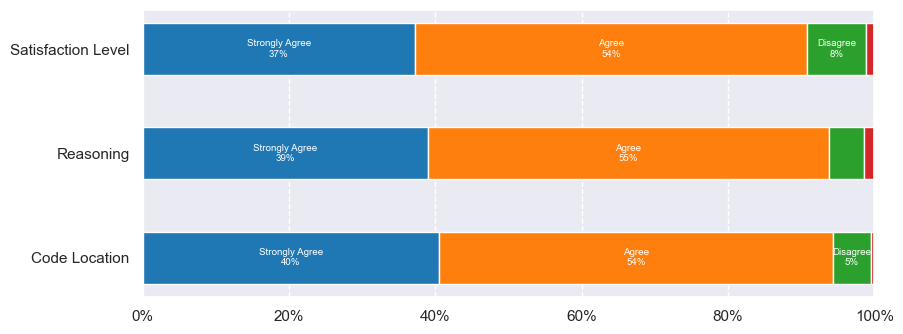

In [93]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import seaborn as sns
from collections import defaultdict
sns.set_theme()

categories = ["Strongly Agree", "Agree", "Disagree", "Strongly Disagree"]
dimensions = {
    "Satisfaction Level": [r["q1_agreement"] for responses in nfr_response.values() for r in responses if not r.get("is_attention_question", False)],
    "Reasoning": [r["q2_agreement"] for responses in nfr_response.values() for r in responses if not r.get("is_attention_question", False)],
    "Code Location": [r["q3_agreement"] for responses in nfr_response.values() for r in responses if not r.get("is_attention_question", False)],
}

results = {}
for dim, values in dimensions.items():
    counts = Counter(values)
    total = len(values)
    results[dim] = {cat: round(counts.get(cat, 0) / total * 100, 1) for cat in categories}

fig, ax = plt.subplots(figsize=(9.2, 3.5))
ax.invert_yaxis()
ax.set_xlim(0, 100)

colors = plt.cm.tab10.colors

for i, (field, subs) in enumerate(results.items()):
    names = list(subs.keys())
    pcts = list(subs.values())
    left = 0
    for j, (name, pct) in enumerate(zip(names, pcts)):
        rect = ax.barh(field, pct, left=left, height=0.5, color=colors[j])
        if pct > 5:
            ax.bar_label(rect, labels=[f'{name}\n{pct:.0f}%'], label_type='center',
                         color='white', fontsize=7)
        left += pct

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.grid(axis='x', linestyle='--', alpha=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [94]:
results = {}
for dim, values in dimensions.items():
    counts = Counter(values)
    total = len(values)
    results[dim] = {cat: counts.get(cat, 0) for cat in categories}
results

{'Satisfaction Level': {'Strongly Agree': 125,
  'Agree': 180,
  'Disagree': 27,
  'Strongly Disagree': 4},
 'Reasoning': {'Strongly Agree': 131,
  'Agree': 184,
  'Disagree': 16,
  'Strongly Disagree': 5},
 'Code Location': {'Strongly Agree': 136,
  'Agree': 181,
  'Disagree': 17,
  'Strongly Disagree': 2}}

Disagreement based on AD

In [95]:
from sklearn.metrics import cohen_kappa_score
import krippendorff
import numpy as np

def build_rating_matrix(nfr_responses, agreement_value, question_key):
    all_pids = list(nfr_responses.keys())
    all_nfrs = sorted({r["nfr_id"] for responses in nfr_responses.values() for r in responses if not r.get("is_attention_question", False)})
    
    matrix = []
    for pid in all_pids:
        row = []
        pid_nfr_map = {r["nfr_id"]: r for r in nfr_responses[pid] if not r.get("is_attention_question", False)}
        for nfr_id in all_nfrs:
            if nfr_id in pid_nfr_map:
                row.append(agreement_value[pid_nfr_map[nfr_id][question_key]])
            else:
                row.append(np.nan)
        matrix.append(row)
    return np.array(matrix, dtype=float), all_nfrs

cutoff = 4 / 6
for q_key, q_label in [("q1_agreement", "Satisfaction"), ("q2_agreement", "Reasoning"), ("q3_agreement", "Code Location")]:
    matrix, nfr_ids = build_rating_matrix(nfr_response, agreement_value, q_key)
    print(q_label)
    for j, nfr in enumerate(nfr_ids):
        col = [matrix[i][j] for i in range(len(matrix)) if not np.isnan(matrix[i][j])]
        mu = np.mean(col)
        ad = np.mean(np.abs(np.array(col) - mu))
        if ad > cutoff:
            print(f"  NFR {nfr}: mean={mu:.2f}, AD={ad:.2f}")

Satisfaction
  NFR 3: mean=2.75, AD=0.88
  NFR 4: mean=3.25, AD=0.75
  NFR 5: mean=3.50, AD=0.75
  NFR 12: mean=2.75, AD=0.75
  NFR 13: mean=3.50, AD=0.75
  NFR 15: mean=3.25, AD=0.75
  NFR 18: mean=2.75, AD=0.88
  NFR 19: mean=3.25, AD=0.75
  NFR 64: mean=3.00, AD=1.00
  NFR 93: mean=3.00, AD=1.00
  NFR 122: mean=3.00, AD=1.00
  NFR 124: mean=3.00, AD=1.00
  NFR 126: mean=3.00, AD=1.00
  NFR 127: mean=2.50, AD=1.50
  NFR 128: mean=3.00, AD=1.00
  NFR 129: mean=3.00, AD=1.00
  NFR 130: mean=2.50, AD=1.50
  NFR 135: mean=3.00, AD=1.00
  NFR 146: mean=3.00, AD=1.00
Reasoning
  NFR 3: mean=2.75, AD=0.88
  NFR 12: mean=2.75, AD=0.88
  NFR 32: mean=2.50, AD=1.50
  NFR 93: mean=3.00, AD=1.00
  NFR 122: mean=3.00, AD=1.00
  NFR 124: mean=3.00, AD=1.00
  NFR 126: mean=3.00, AD=1.00
  NFR 127: mean=3.00, AD=1.00
  NFR 128: mean=3.00, AD=1.00
  NFR 129: mean=3.00, AD=1.00
  NFR 130: mean=2.50, AD=1.50
  NFR 135: mean=2.00, AD=1.00
  NFR 146: mean=3.00, AD=1.00
Code Location
  NFR 3: mean=2.75, A

In [96]:
from sklearn.metrics import cohen_kappa_score
import krippendorff
import numpy as np

def build_rating_matrix(nfr_responses, agreement_value, question_key):
    all_pids = list(nfr_responses.keys())
    all_nfrs = sorted({r["nfr_id"] for responses in nfr_responses.values() for r in responses if not r.get("is_attention_question", False)})
    
    matrix = []
    for pid in all_pids:
        row = []
        pid_nfr_map = {r["nfr_id"]: r for r in nfr_responses[pid] if not r.get("is_attention_question", False)}
        for nfr_id in all_nfrs:
            if nfr_id in pid_nfr_map:
                row.append(agreement_value[pid_nfr_map[nfr_id][question_key]])
            else:
                row.append(np.nan)
        matrix.append(row)
    return np.array(matrix, dtype=float), all_nfrs

for q_key, q_label in [("q1_agreement", "Satisfaction"), ("q2_agreement", "Reasoning"), ("q3_agreement", "Code Location")]:
    matrix, nfr_ids = build_rating_matrix(nfr_response, agreement_value, q_key)
    #print(matrix)
    alpha = krippendorff.alpha(reliability_data=matrix, level_of_measurement='ordinal')
    print(f"{q_label} — Krippendorff's α: {alpha:.3f}")

Satisfaction — Krippendorff's α: -0.099
Reasoning — Krippendorff's α: -0.061
Code Location — Krippendorff's α: -0.122


In [97]:
import numpy as np
import pandas as pd
from scipy import stats

agreement_value = {"Strongly Agree":4, "Agree": 3, "Disagree": 2, "Strongly Disagree": 1}

# Build a tidy long-form DataFrame — this is the foundation for everything
records = []
for pid, responses in nfr_response.items():
    for r in responses:
        if r.get("is_attention_question", False):
            continue
        records.append({
            "participant": pid,
            "nfr_id": r["nfr_id"],
            "satisfaction": agreement_value[r["q1_agreement"]],
            "reasoning":    agreement_value[r["q2_agreement"]],
            "code_location": agreement_value[r["q3_agreement"]],
        })

df = pd.DataFrame(records)

###
from scipy.stats import ttest_1samp

print("=== Test 1: Is agreement significantly above 3? ===")
print("H0: mean <= 3 | H1: mean > 3\n")

for dim, label in zip(["satisfaction", "reasoning", "code_location"],
                       ["Satisfaction Level", "Reasoning", "Code Location"]):
    scores = df[dim].values
    #print(scores)
    stat, p = ttest_1samp(scores, popmean=3, alternative="greater")
    mean_val = np.mean(scores)
    std_val = np.std(scores, ddof=1)
    print(f"{label}:")
    print(f"  Mean = {mean_val:.3f}, SD = {std_val:.3f}")
    print(f"  t = {stat:.3f}, p = {p:.4f} ({'significant' if p < 0.05 else 'not significant'})\n")

=== Test 1: Is agreement significantly above 3? ===
H0: mean <= 3 | H1: mean > 3

Satisfaction Level:
  Mean = 3.268, SD = 0.655
  t = 7.492, p = 0.0000 (significant)

Reasoning:
  Mean = 3.312, SD = 0.633
  t = 9.051, p = 0.0000 (significant)

Code Location:
  Mean = 3.342, SD = 0.603
  t = 10.411, p = 0.0000 (significant)

